Installed Packages ScottPlot, 5.0.55

Loading extensions from `C:\Users\Home\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`


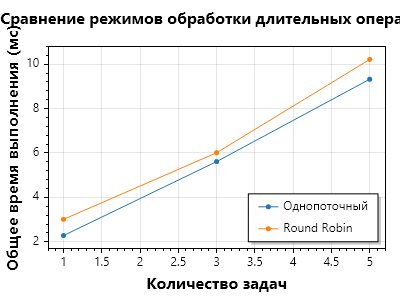

In [1]:
#r "nuget:ScottPlot, 5.0.*"
#r "nuget:SkiaSharp.NativeAssets.Linux.NoDependencies"

using System.Collections.Generic;
using System.IO;
using System.Linq;
using Microsoft.DotNet.Interactive.Formatting;
using ScottPlot;

Formatter.Register(typeof(Plot), (p, w) => w.Write(((Plot)p).GetPngHtml(400, 300)), "text/html");

var lines = File.ReadAllLines("/home/ome23/practice/practice2025/graph_data.txt");

var tasks  = new List<double>();
var single = new List<double>();
var pseudo = new List<double>();

foreach (var l in lines)
{
    var p = l.Split(':');
    if (p.Length < 3) continue; 
    tasks .Add(double.Parse(p[0]));
    single.Add(double.Parse(p[1]));
    pseudo.Add(double.Parse(p[2]));
}

var plt = new Plot();
plt.Add.Scatter(tasks.ToArray(), single.ToArray()).Label = "Однопоточный";
plt.Add.Scatter(tasks.ToArray(), pseudo.ToArray()).Label = "Round Robin";

plt.XLabel("Количество задач");
plt.YLabel("Общее время выполнения (мс)");
plt.Title("Сравнение режимов обработки длительных операций");
plt.ShowLegend();

plt.SavePng("/home/ome23/practice/practice2025/task18_plot.png", 600, 400);

plt